<a href="https://colab.research.google.com/github/PALAK7890/Indian_Crime/blob/main/Crime.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
url='https://raw.githubusercontent.com/PALAK7890/Indian_Crime/refs/heads/main/india_crime_dataset.csv'
df=pd.read_csv(url)
df.head()

,fir_number,date_reported,year,city,state,primary_crime_type,description,ipc_section,location_type,beat_zone,victim_age,victim_gender,arrest_made,case_status,severity,latitude,longitude
0,fir/pun/2015/4628,05 May 2015 04:56 PM,2015,Pune,Maharashtra,VEHICLE THEFT,Two Wheeler,IPC 379,Street,NaN,54.0,Male,NaN,CHARGE SHEETED,Low,18.602007,73.963196
1,FIR/AHM/2021/2730,08/02/2021 13:57:00,2021,Ahmedabad,Gujarat,VEHICLE THEFT,Car Theft,ipc 379,MARKET,23.0,63.0,MALE,No,Closed,Low,23.157595,72.713810
2,PUN-2017-4991,14/10/2017 16:19:00,2017,Pune,Maharashtra,COUNTERFEITING,fake currency,489A IPC,Residence,18.0,58.0,Male,no,Under Investigation,Low,18.425002,73.793409
3,FIR/MUM/2017/9525,13/08/17 13:11,2017,Mumbai,Maharashtra,FRAUD/CHEATING,UPI Fraud,IPC-420,ATM,8.0,26.0,FEMALE,yes,Pending Trial,Low,19.070575,72.949740
4,FIR92792023,28/10/2023 23:58:00,2023,Mumbai,Maharashtra,KIDNAPPING,Abduction for Ransom,IPC 363,SCHOOL,20.0,7.0,m,NaN,under investigation,High,18.927087,72.858727


In [3]:
 df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   fir_number          60000 non-null  object 
 1   date_reported       60000 non-null  object 
 2   year                60000 non-null  int64  
 3   city                60000 non-null  object 
 4   state               60000 non-null  object 
 5   primary_crime_type  60000 non-null  object 
 6   description         60000 non-null  object 
 7   ipc_section         60000 non-null  object 
 8   location_type       56722 non-null  object 
 9   beat_zone           55784 non-null  float64
 10  victim_age          54616 non-null  float64
 11  victim_gender       53331 non-null  object 
 12  arrest_made         46136 non-null  object 
 13  case_status         55938 non-null  object 
 14  severity            60000 non-null  object 
 15  latitude            54036 non-null  float64
 16  long

In [4]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 57000 entries, 0 to 59998
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   fir_number          57000 non-null  object 
 1   date_reported       57000 non-null  object 
 2   year                57000 non-null  int64  
 3   city                57000 non-null  object 
 4   state               57000 non-null  object 
 5   primary_crime_type  57000 non-null  object 
 6   description         57000 non-null  object 
 7   ipc_section         57000 non-null  object 
 8   location_type       53910 non-null  object 
 9   beat_zone           53010 non-null  float64
 10  victim_age          51880 non-null  float64
 11  victim_gender       50652 non-null  object 
 12  arrest_made         43861 non-null  object 
 13  case_status         53136 non-null  object 
 14  severity            57000 non-null  object 
 15  latitude            51336 non-null  float64
 16  longitude

In [6]:
df.shape

(57000, 17)

<Axes: >

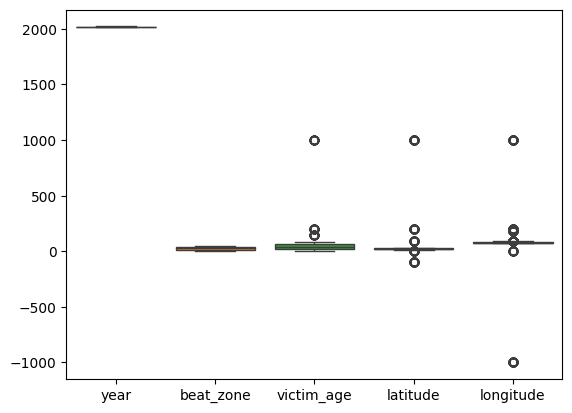

In [7]:
df_num=df.select_dtypes(include='number')
sns.boxplot(data=df_num)

<Axes: ylabel='victim_age'>

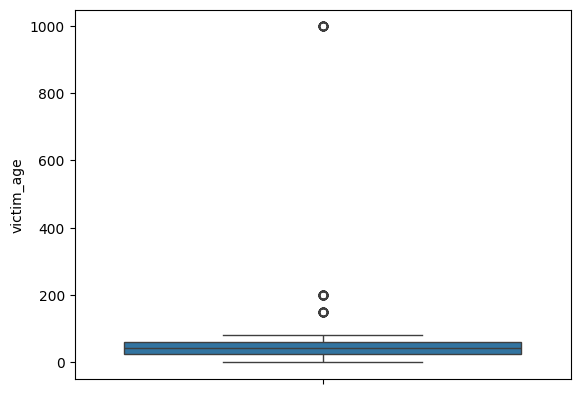

In [8]:
sns.boxplot(data=df['victim_age'])

In [9]:
df['victim_age'].describe()

,victim_age
count,51880.000000
mean,42.678065
std,31.461715
min,-1.000000
25%,23.000000
50%,42.000000
75%,61.000000
max,999.000000


In [10]:
df = df[(df['victim_age'] >= 1) & (df['victim_age'] <= 100)]
df['victim_age'].describe()

,victim_age
count,51730.000000
mean,42.027740
std,21.689746
min,5.000000
25%,23.000000
50%,42.000000
75%,61.000000
max,79.000000


In [11]:
df['longitude'].describe()

,longitude
count,46563.000000
mean,78.262954
std,50.921377
min,-999.000000
25%,73.930352
50%,77.301812
75%,80.235602
max,999.000000


In [12]:
print((df['longitude'] > 180).sum())
print((df['longitude'] < -180).sum())

177
55


In [13]:
df = df[(df['longitude'] >= -180) & (df['longitude'] <= 180)]

In [14]:
df['longitude'].describe()

,longitude
count,46331.000000
mean,77.997603
std,5.150349
min,0.000000
25%,73.929988
50%,77.289129
75%,80.227071
max,91.885773


In [15]:
df['latitude'].describe()

,latitude
count,46331.000000
mean,21.457324
std,15.509502
min,-99.000000
25%,17.527804
50%,21.237167
75%,26.394056
max,999.000000


In [16]:
df = df[(df['latitude'] >= -90) & (df['latitude'] <= 90)]
df['latitude'].describe()

,latitude
count,46303.000000
mean,21.234375
std,5.365515
min,0.000000
25%,17.527676
50%,21.236368
75%,26.390990
max,30.882288


In [17]:
df = df[(df['latitude'] != 0) & (df['longitude'] != 0)]

<Axes: >

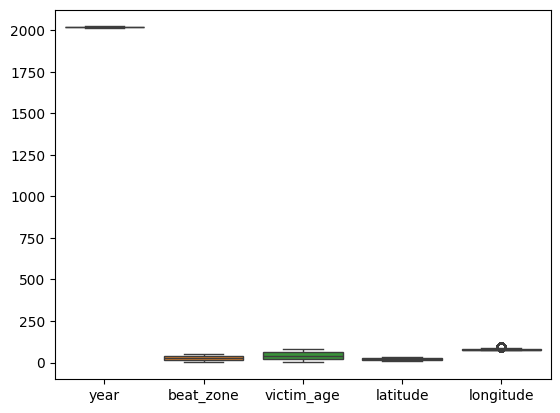

In [18]:
df_num=df.select_dtypes(include='number')
sns.boxplot(data=df_num)

In [19]:
df['victim_age']=df['victim_age'].fillna(df['victim_age'].median())
df['victim_age'] = df['victim_age'].astype(int)
df['beat_zone'] = df['beat_zone'].fillna(df['beat_zone'].median())
df['beat_zone'] = df['beat_zone'].astype(int)


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 46294 entries, 0 to 59998
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   fir_number          46294 non-null  object 
 1   date_reported       46294 non-null  object 
 2   year                46294 non-null  int64  
 3   city                46294 non-null  object 
 4   state               46294 non-null  object 
 5   primary_crime_type  46294 non-null  object 
 6   description         46294 non-null  object 
 7   ipc_section         46294 non-null  object 
 8   location_type       43751 non-null  object 
 9   beat_zone           46294 non-null  int64  
 10  victim_age          46294 non-null  int64  
 11  victim_gender       41101 non-null  object 
 12  arrest_made         35659 non-null  object 
 13  case_status         43135 non-null  object 
 14  severity            46294 non-null  object 
 15  latitude            46294 non-null  float64
 16  longitude

In [21]:

df['date_reported'] = pd.to_datetime(
    df['date_reported'],
    errors='coerce',
    dayfirst=True
)
df['date_reported'] = df['date_reported'].fillna(
    pd.to_datetime(df['year'], format='%Y')
)


/tmp/ipykernel_23508/3534150224.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date_reported'] = pd.to_datetime(


<Axes: xlabel='ipc_final', ylabel='Count'>

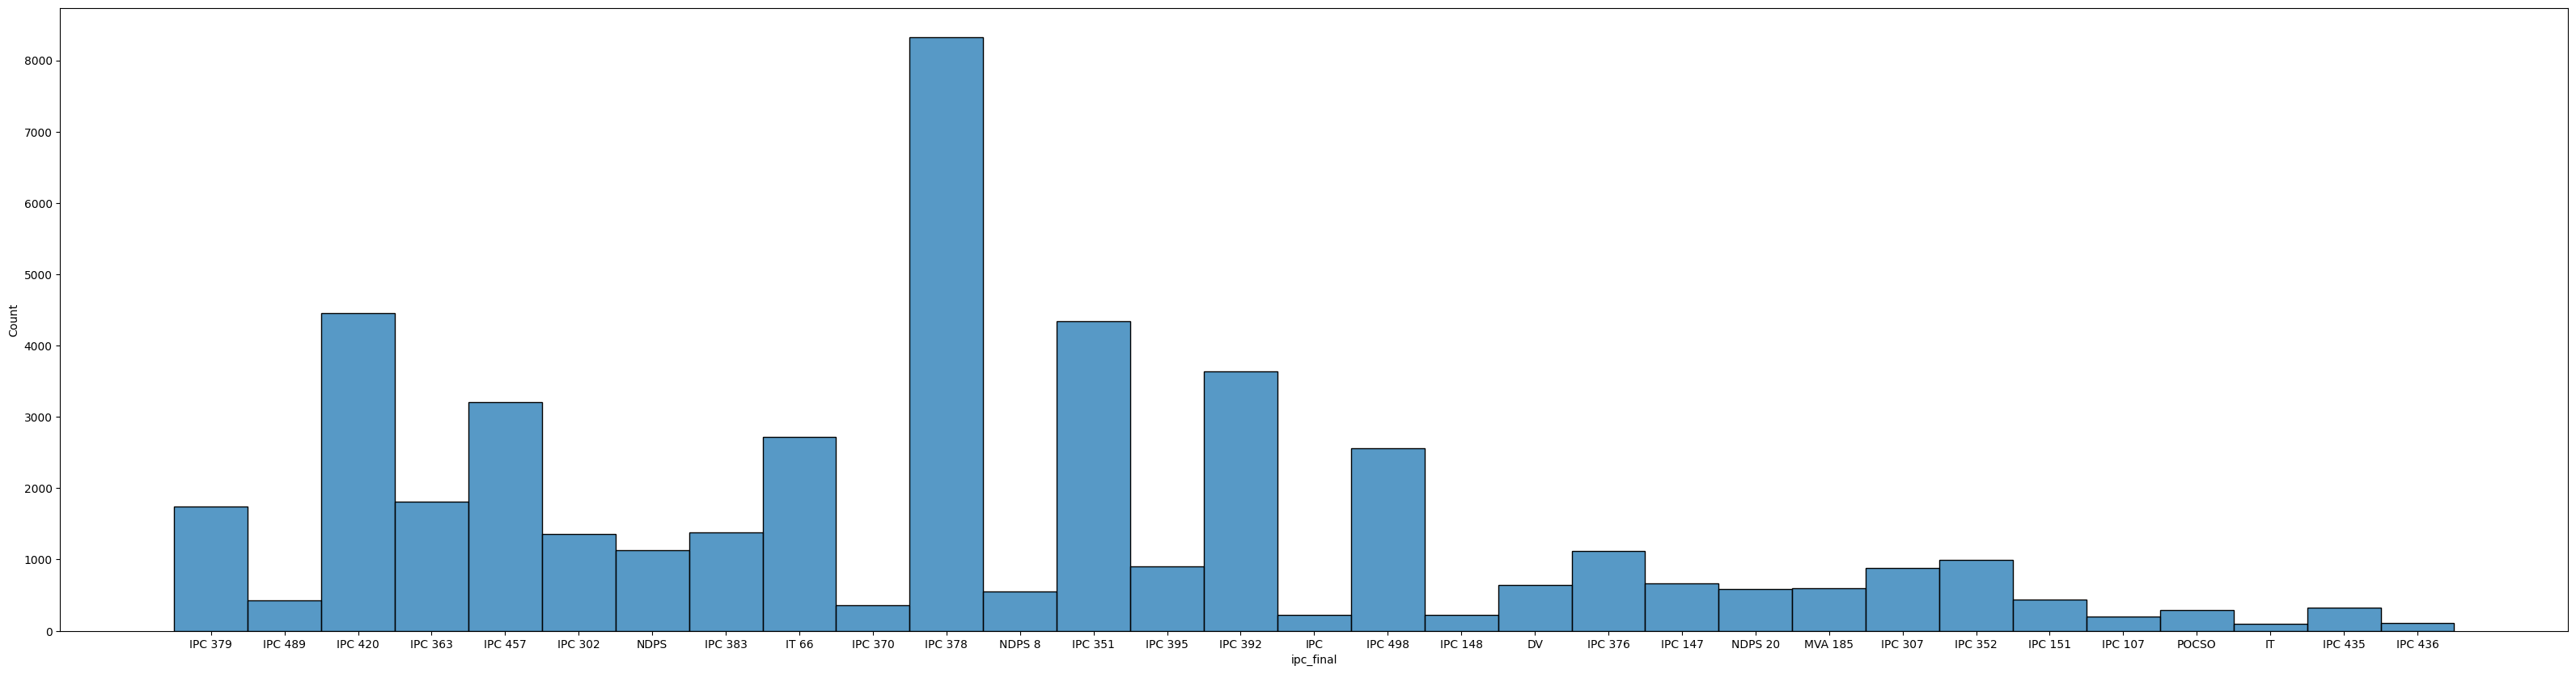

In [22]:
col = df['ipc_section'].astype(str).str.lower().str.strip()
col = col.replace(r'[.\*]',' ',regex=True)
col= col.str.replace(r'\s+', ' ', regex=True).str.strip()
numbers = col.str.extract(r'(\d+[a-zA-Z]*?)')[0]
numbers= numbers.str.replace(' ','',regex=True).str.upper()
df['law_type'] = np.select(
    [
        col.str.contains('pocso'),
        col.str.contains('ndps'),
        col.str.contains('it'),
        col.str.contains('mva'),
        col.str.contains('dv'),
        col.str.contains('ipc') | numbers.notna()
    ],
    [
        'POCSO',
        'NDPS',
        'IT',
        'MVA',
        'DV',
        'IPC'
    ],
    default='OTHER'
)
df['ipc_final'] = np.where(
    df['law_type'].isin(['POCSO', 'DV'])| numbers.isna(),
    df['law_type'],
   df['law_type'] + ' ' + numbers
)

plt.figure(figsize=(40,10))

sns.histplot(df['ipc_final'])


In [23]:
df['arrest_made'] = df['arrest_made'].astype(str).str.strip().str.lower()

df['arrest_made'] = df['arrest_made'].map({
    'yes': True, 'y': True, 'true': True,
    'no': False, 'n': False, 'false': False
})
df['arrest_made']=df['arrest_made'].fillna(df['arrest_made'].mode()[0])

/tmp/ipykernel_23508/4220669320.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['arrest_made']=df['arrest_made'].fillna(df['arrest_made'].mode()[0])


In [24]:
df['case_status']=df['case_status'].str.lower()
df['case_status']=df['case_status'].fillna(df['case_status'].mode()[0])

In [25]:
df['location_type']=df['location_type'].str.lower()
df['location_type']=df['location_type'].fillna('unknown')

In [26]:
df['victim_gender']=df['victim_gender'].str.lower()
df['victim_gender'] = df['victim_gender'].map({
    'male': 'male', 'm': 'male',
    'female': 'female', 'f': 'female',
    'unknown':'Unknown'
})
df['victim_gender'] = df['victim_gender'].fillna('Unknown')
df['victim_gender'] = df['victim_gender'].str.lower()

In [27]:
df['description']=df['description'].str.lower()


In [28]:
df['severity']=df['severity'].str.lower()

In [29]:
df['case_status'].value_counts()

,count
case_status,
charge sheeted,12459
under investigation,9294
closed,9268
convicted,6176
pending trial,6122
acquitted,2975


In [30]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 46294 entries, 0 to 59998
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   fir_number          46294 non-null  object        
 1   date_reported       46294 non-null  datetime64[ns]
 2   year                46294 non-null  int64         
 3   city                46294 non-null  object        
 4   state               46294 non-null  object        
 5   primary_crime_type  46294 non-null  object        
 6   description         46294 non-null  object        
 7   ipc_section         46294 non-null  object        
 8   location_type       46294 non-null  object        
 9   beat_zone           46294 non-null  int64         
 10  victim_age          46294 non-null  int64         
 11  victim_gender       46294 non-null  object        
 12  arrest_made         46294 non-null  bool          
 13  case_status         46294 non-null  object        


 **Doing EDA**


In [31]:
print("-"*45)
print("DATASET OVERVIEW")
print("-"*45)
print(f"Total Records:  {len(df):,}")
print(f"Date Range:     {df['date_reported'].min().year} → {df['date_reported'].max().year}")
print(f"Cities Covered: {df['city'].nunique()}")
print(f"Crime Types:    {df['primary_crime_type'].nunique()}")
print(f"Arrest Rate:    {df['arrest_made'].mean()*100:.1f}%")
print(f"\nTop 5 Cities:")
print(df['city'].value_counts().head())
print(f"\nTop 5 Crimes:")
print(df['primary_crime_type'].value_counts().head())

---------------------------------------------
DATASET OVERVIEW
---------------------------------------------
Total Records:  46,294
Date Range:     2015 → 2023
Cities Covered: 20
Crime Types:    20
Arrest Rate:    21.9%

Top 5 Cities:
city
Mumbai       5869
Delhi        5383
Bangalore    4048
Hyderabad    3577
Kolkata      3201
Name: count, dtype: int64

Top 5 Crimes:
primary_crime_type
THEFT                8321
ASSAULT              5334
FRAUD/CHEATING       4449
ROBBERY              3633
DOMESTIC VIOLENCE    3207
Name: count, dtype: int64


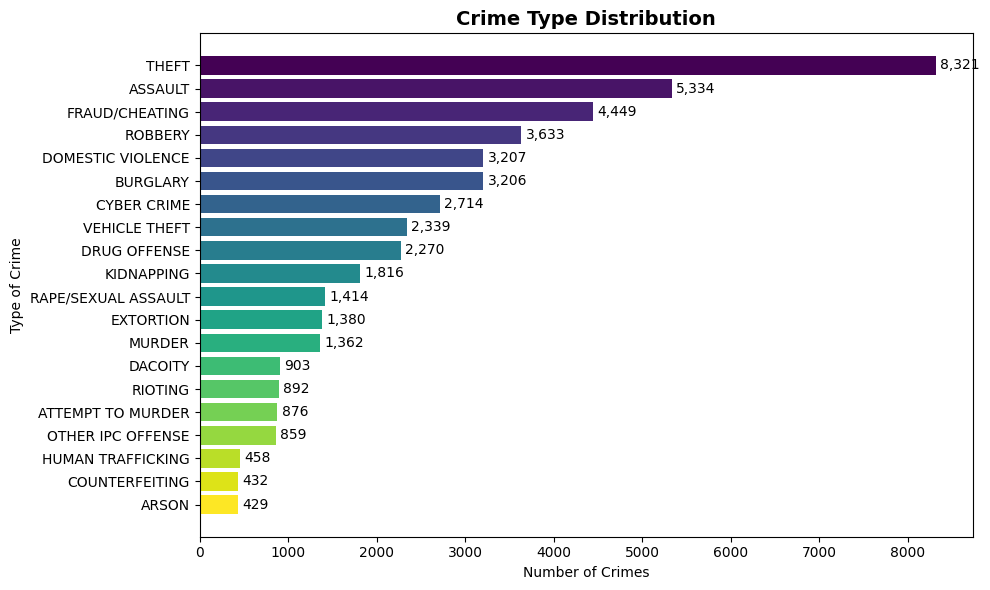

In [32]:
crime_counts = df['primary_crime_type'].value_counts()
plt.figure(figsize=(10, 6))
colors=plt.cm.viridis(np.linspace(0,1,len(crime_counts)))
bars=plt.barh(crime_counts.index, crime_counts.values,color=colors)
plt.xlabel('Number of Crimes')
plt.ylabel('Type of Crime')
plt.title('Crime Type Distribution', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
for bar,val in zip(bars,crime_counts.values):
    plt.text(
        bar.get_width() + 50,
        bar.get_y() + bar.get_height()/2,
        f'{val:,}',
        va='center'
    )

plt.tight_layout()
plt.show()


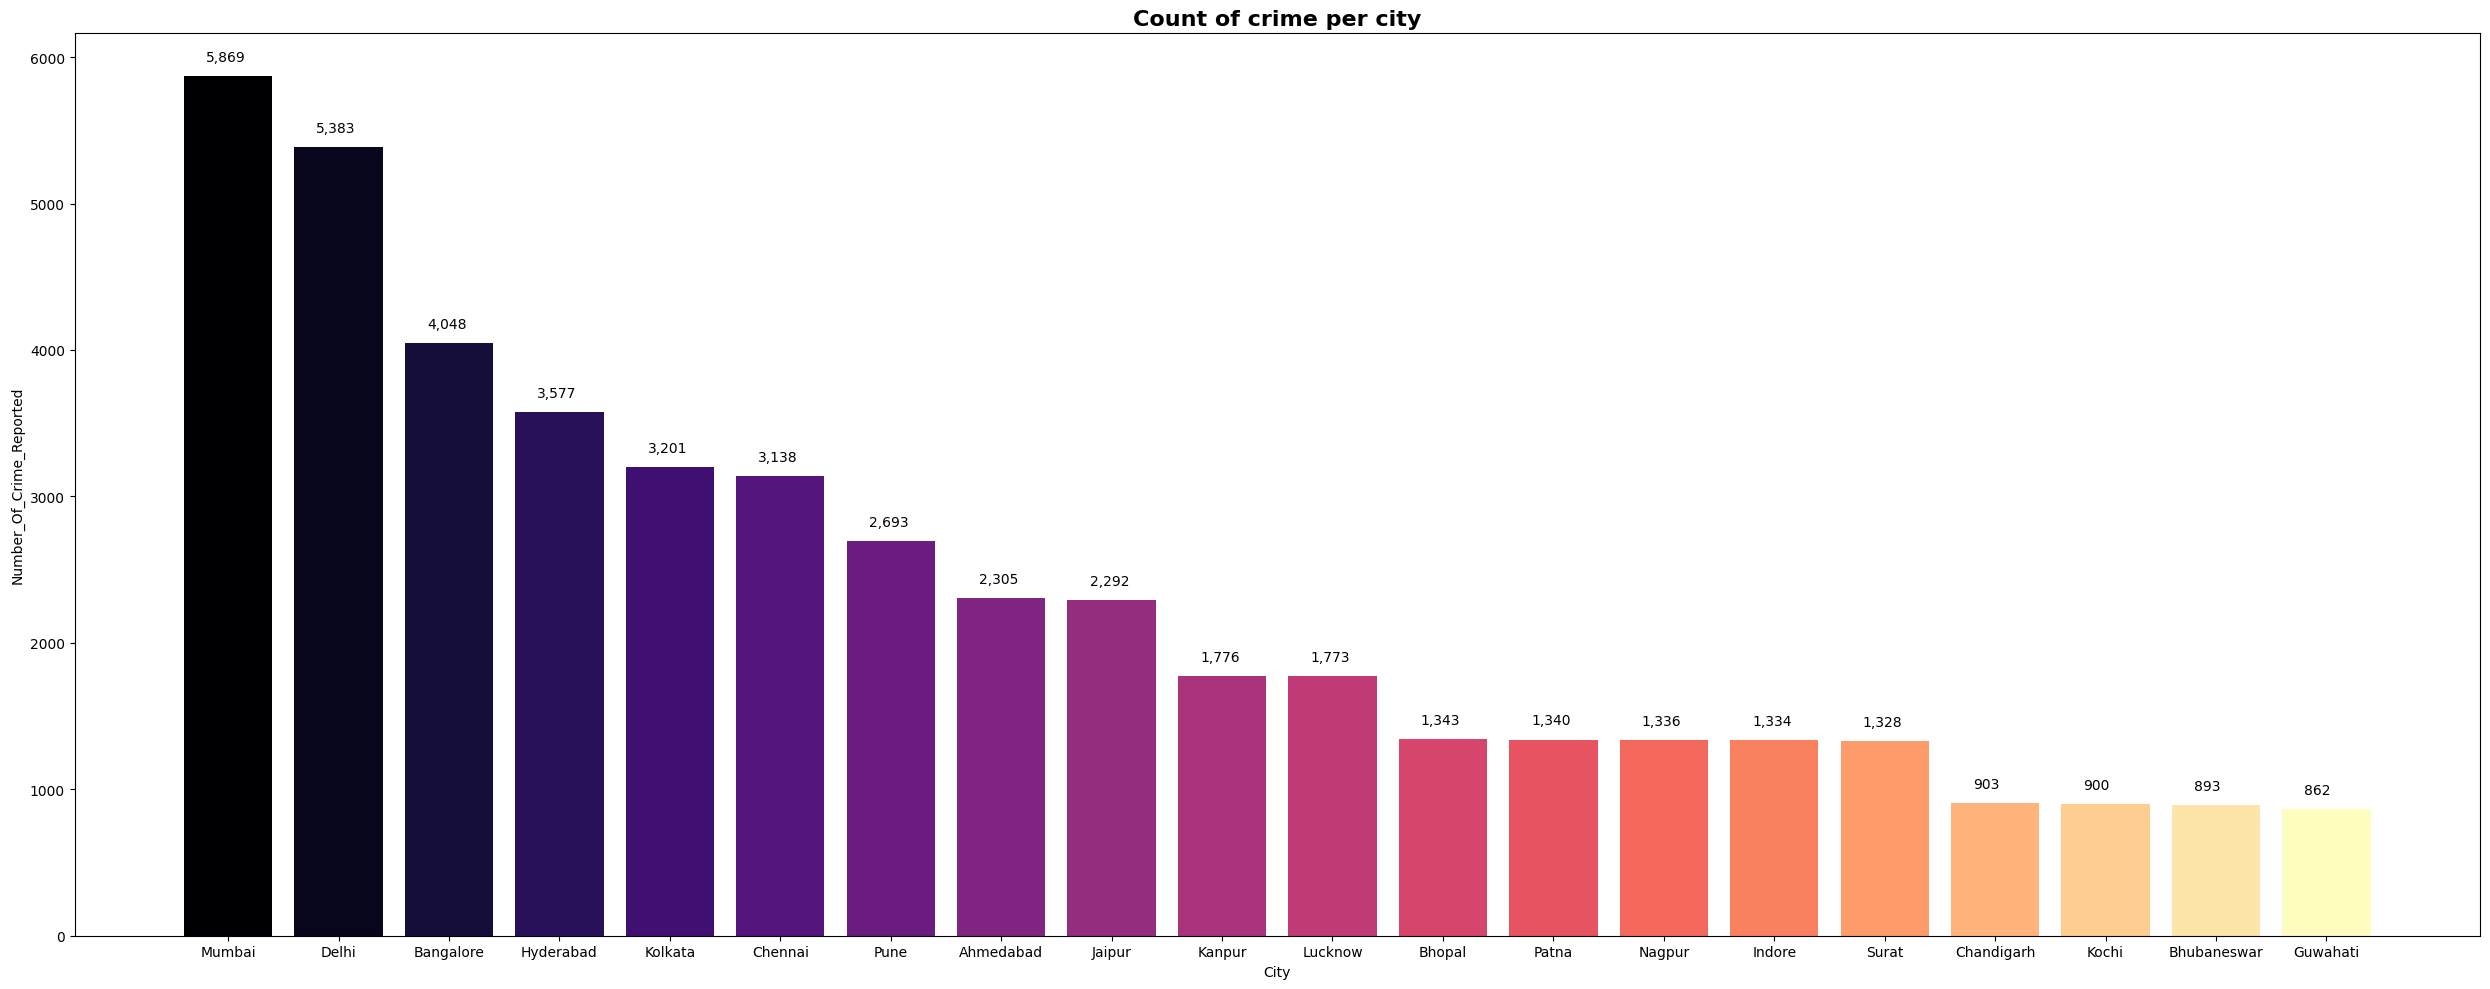

In [33]:
crime_city=df.groupby('city').size().sort_values(ascending=False)
plt.figure(figsize=(25,10))
bars=plt.bar(crime_city.index,crime_city.values,color=plt.cm.magma(np.linspace(0,1,len(crime_city))))
plt.xlabel('City')
plt.ylabel('Number_Of_Crime_Reported')
plt.title('Count of crime per city',fontsize=16,fontweight='bold')
for bar,val in zip(bars,crime_city.values):
    plt.text(bar.get_x()+bar.get_width()/4,bar.get_height()+130,f'{val:,}',va='center')
plt.tight_layout()
plt.show()


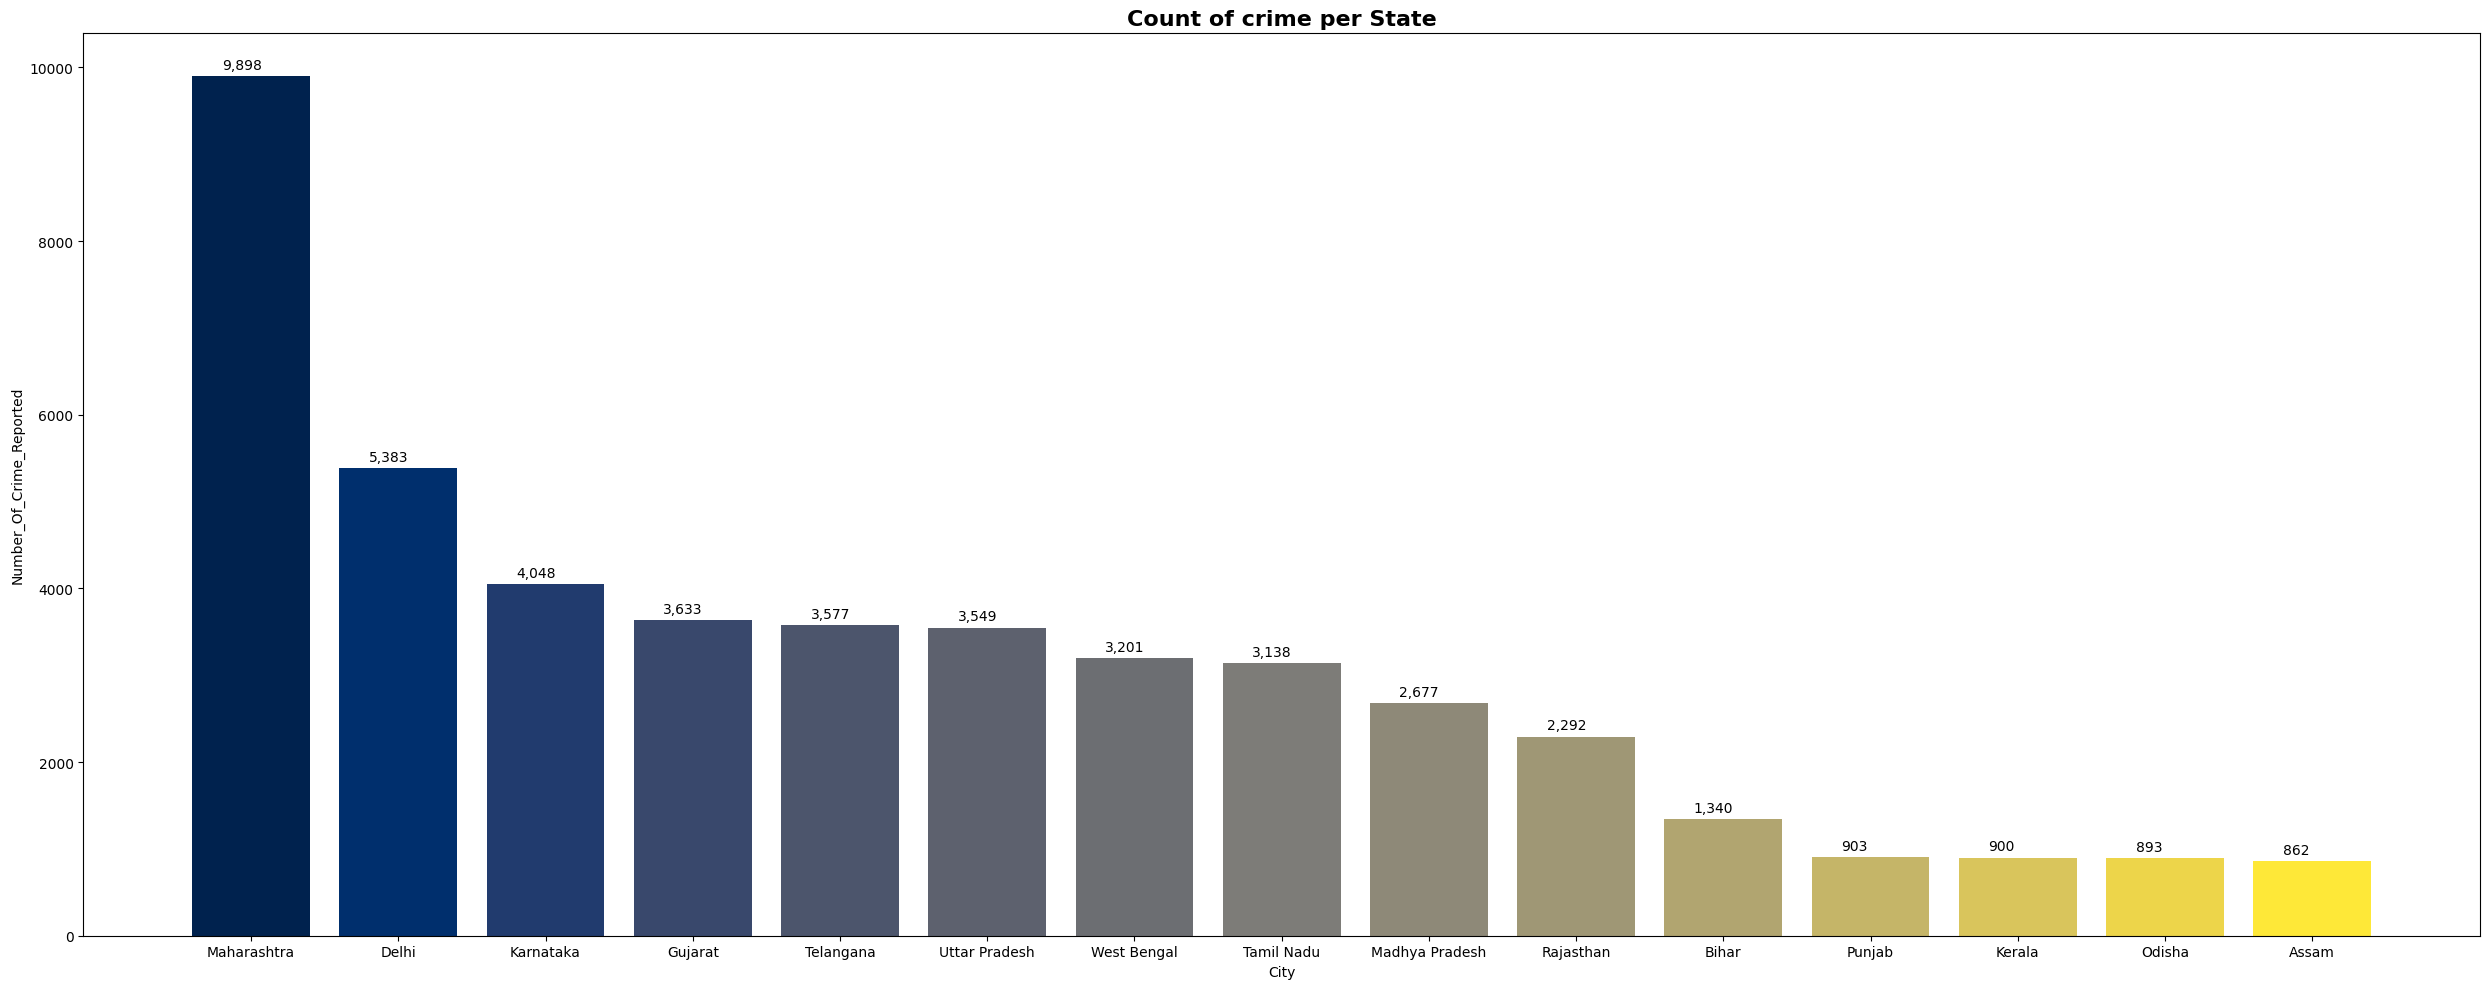

In [34]:
crime_city=df.groupby('state').size().sort_values(ascending=False)
plt.figure(figsize=(25,10))
bars=plt.bar(crime_city.index,crime_city.values,color=plt.cm.cividis(np.linspace(0,1,len(crime_city))))
plt.xlabel('City')
plt.ylabel('Number_Of_Crime_Reported')
plt.title('Count of crime per State',fontsize=16,fontweight='bold')
for bar,val in zip(bars,crime_city.values):
    plt.text(bar.get_x()+bar.get_width()/4,bar.get_height()+130,f'{val:,}',va='center')
plt.tight_layout()
plt.show()

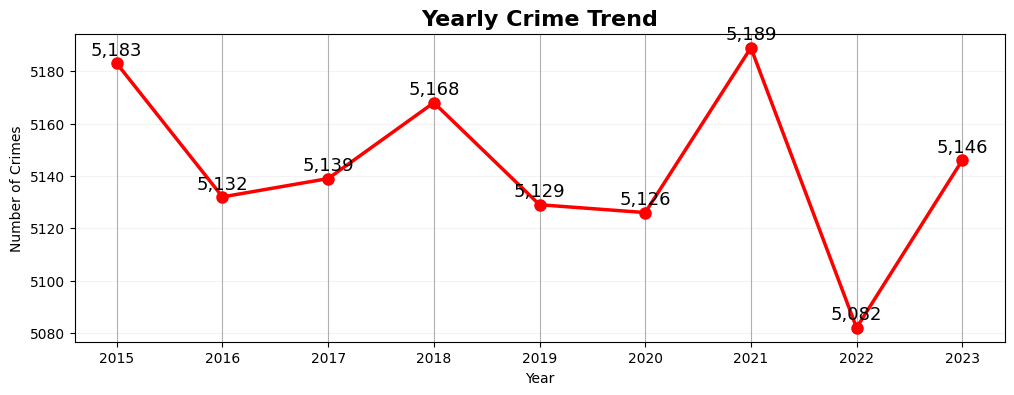

In [35]:
yearly_trend=df.groupby('year').size().reset_index(name='Crime over years')
plt.figure(figsize=(12,4))
plt.plot(yearly_trend['year'],yearly_trend['Crime over years'],marker='o',linewidth=2.5,color='red',markersize=8)
# plt.fill_between(yearly_trend['year'],yearly_trend['Crime over years'],color='red',alpha=0.15)
for _, row in yearly_trend.iterrows():
    plt.text(row['year'], row['Crime over years'] +3, f"{int(row['Crime over years']):,}",ha='center', fontsize=13)
plt.xlabel('Year')
plt.ylabel('Number of Crimes')
plt.title('Yearly Crime Trend',fontsize=16,fontweight='bold')
plt.grid(axis='y', alpha=0.15)
plt.grid(True)

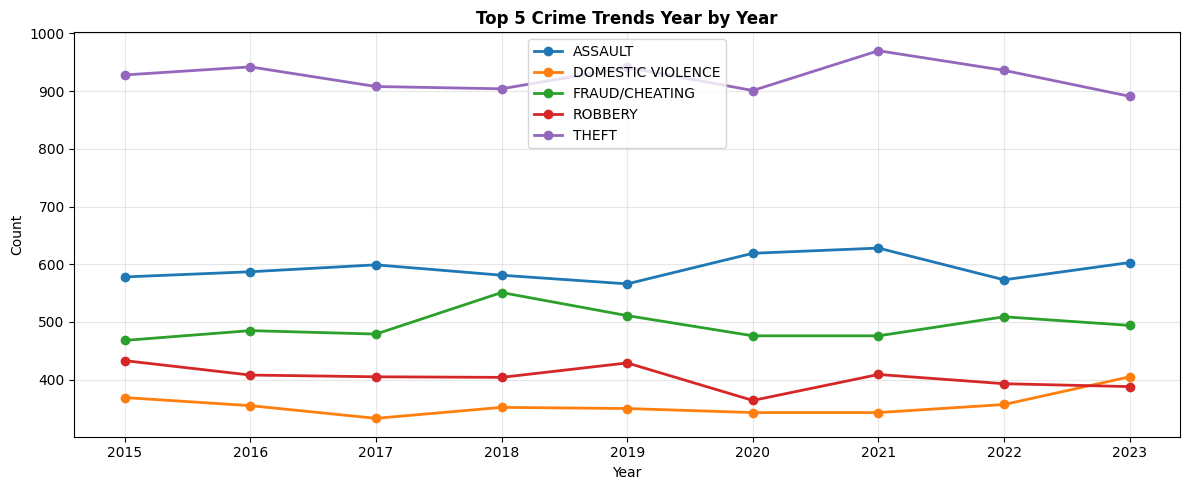

In [36]:
top5_crimes = df['primary_crime_type'].value_counts().head(5).index
crime_yearly = df[df['primary_crime_type'].isin(top5_crimes)]
crime_yearly = crime_yearly.groupby(['year','primary_crime_type']).size().unstack(fill_value=0)
plt.figure(figsize=(12,5))
for col in crime_yearly.columns:
    plt.plot(crime_yearly.index, crime_yearly[col], marker='o', label=col, linewidth=2)
plt.title('Top 5 Crime Trends Year by Year', fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Count')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

<Axes: xlabel='day_of_week', ylabel='hour'>

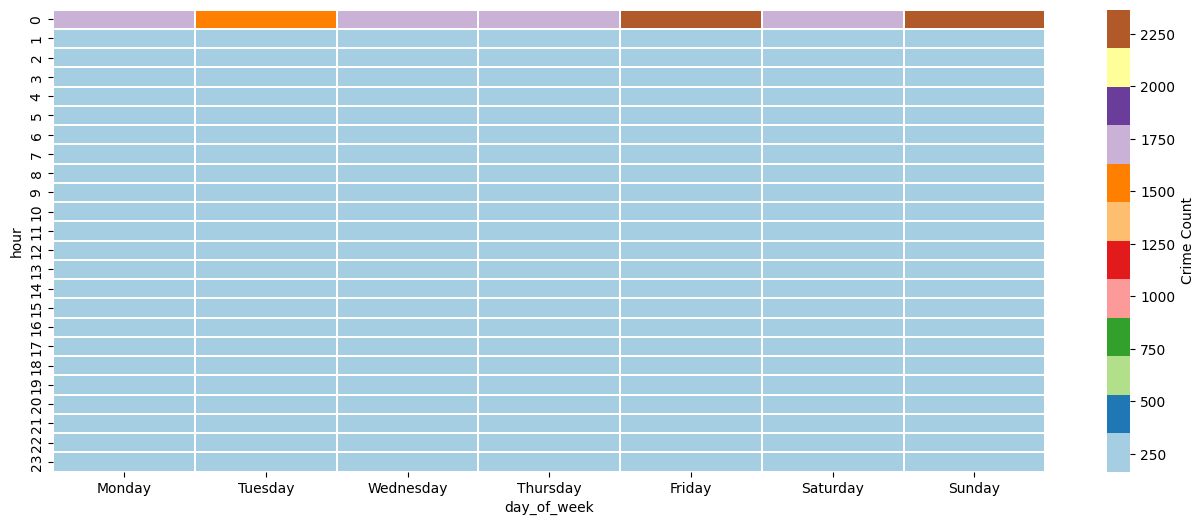

In [37]:
df['hour']=df['date_reported'].dt.hour
df['day_of_week']=df['date_reported'].dt.day_name()
day_order = ['Monday','Tuesday','Wednesday',
             'Thursday','Friday','Saturday','Sunday']
crime_pivot=df.groupby(['hour','day_of_week']).size().unstack(fill_value=0)
crime_pivot = crime_pivot.reindex(columns=day_order)
plt.figure(figsize=(16, 6))
sns.heatmap(crime_pivot,cmap='Paired',cbar_kws={'label': 'Crime Count'},linewidths=0.3)

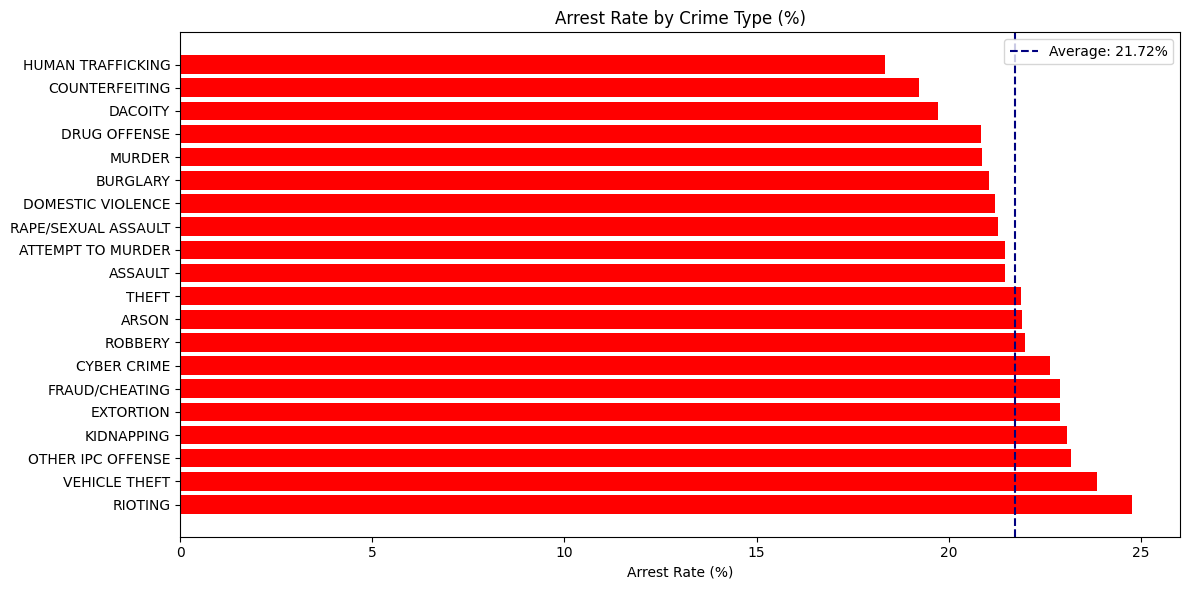

In [38]:
arrest_rate=df.groupby('primary_crime_type')['arrest_made'].mean()*100
arrest_rate=arrest_rate.sort_values(ascending=False)
colors = ['green' if x > 25 else 'red' for x in arrest_rate.values]
plt.figure(figsize=(12,6))
bars = plt.barh(arrest_rate.index, arrest_rate.values, color=colors)
plt.title('Arrest Rate by Crime Type (%)')
plt.xlabel('Arrest Rate (%)')
plt.axvline(
    x=arrest_rate.mean(),color='navy',linestyle='--', label=f'Average: {round(arrest_rate.mean(),2)}%')
plt.legend()
plt.tight_layout()


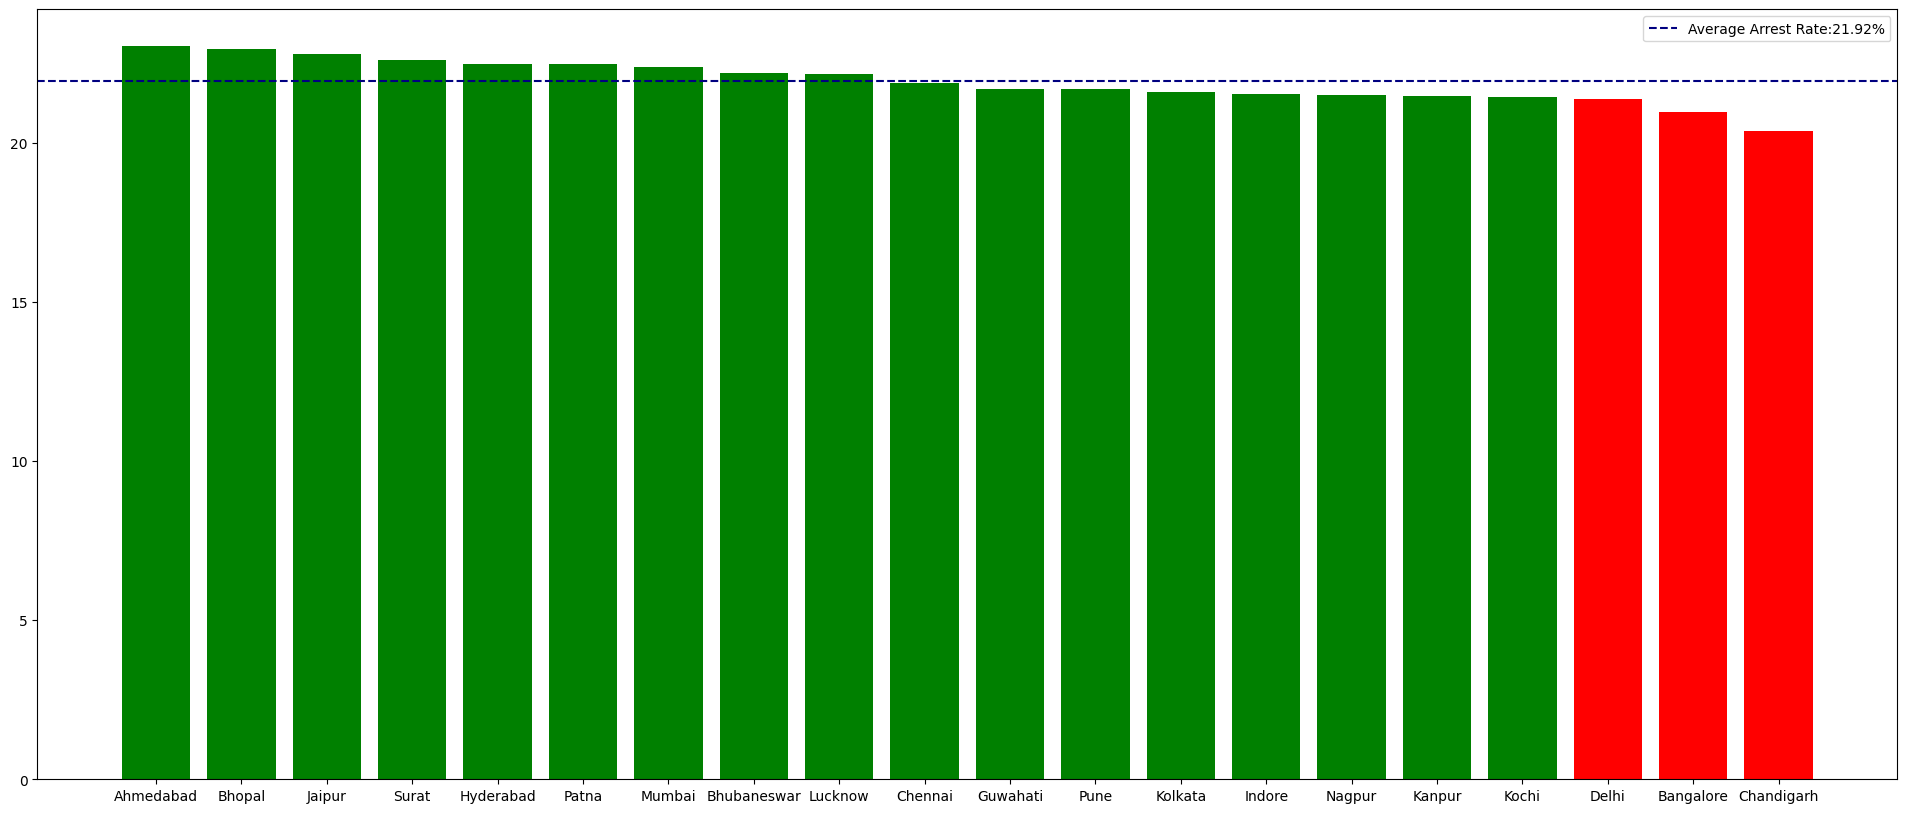

In [39]:
city_arrest_rate=df.groupby('city')['arrest_made'].mean()*100
city_arrest_rate=city_arrest_rate.sort_values(ascending=False)
plt.figure(figsize=(24,10))
colors = ['green' if x > 20 else 'red' for x in arrest_rate.values]
bars=plt.bar(city_arrest_rate.index,city_arrest_rate.values,color=colors)
plt.axhline(y=city_arrest_rate.mean(),color='navy',linestyle='--',label=f'Average Arrest Rate:{round(city_arrest_rate.mean(),2)}%')
plt.legend()

Text(0, 0.5, 'Count')

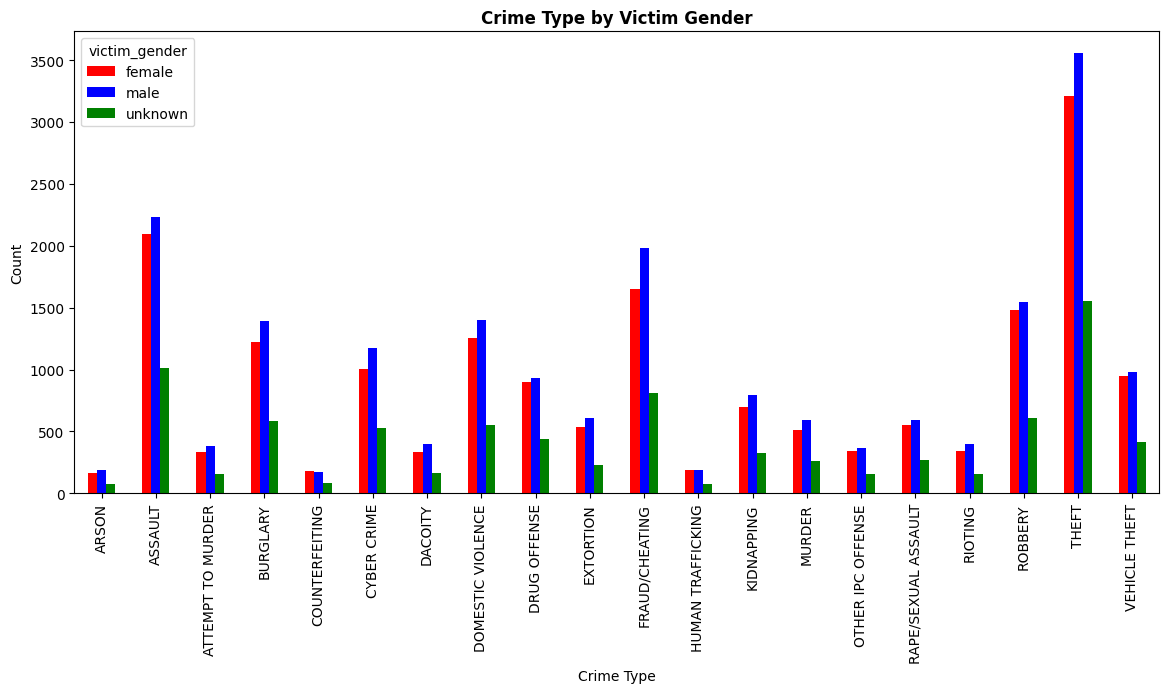

In [40]:
gender_crime=df.groupby(['primary_crime_type','victim_gender']).size().unstack(fill_value=0)
gender_crime.plot(kind='bar',figsize=(14,6),color=['red','blue','green'])
plt.title('Crime Type by Victim Gender',fontweight='bold')
plt.xlabel('Crime Type')
plt.ylabel('Count')

Text(0.5, 1.0, 'Crime Type by Victim Age')

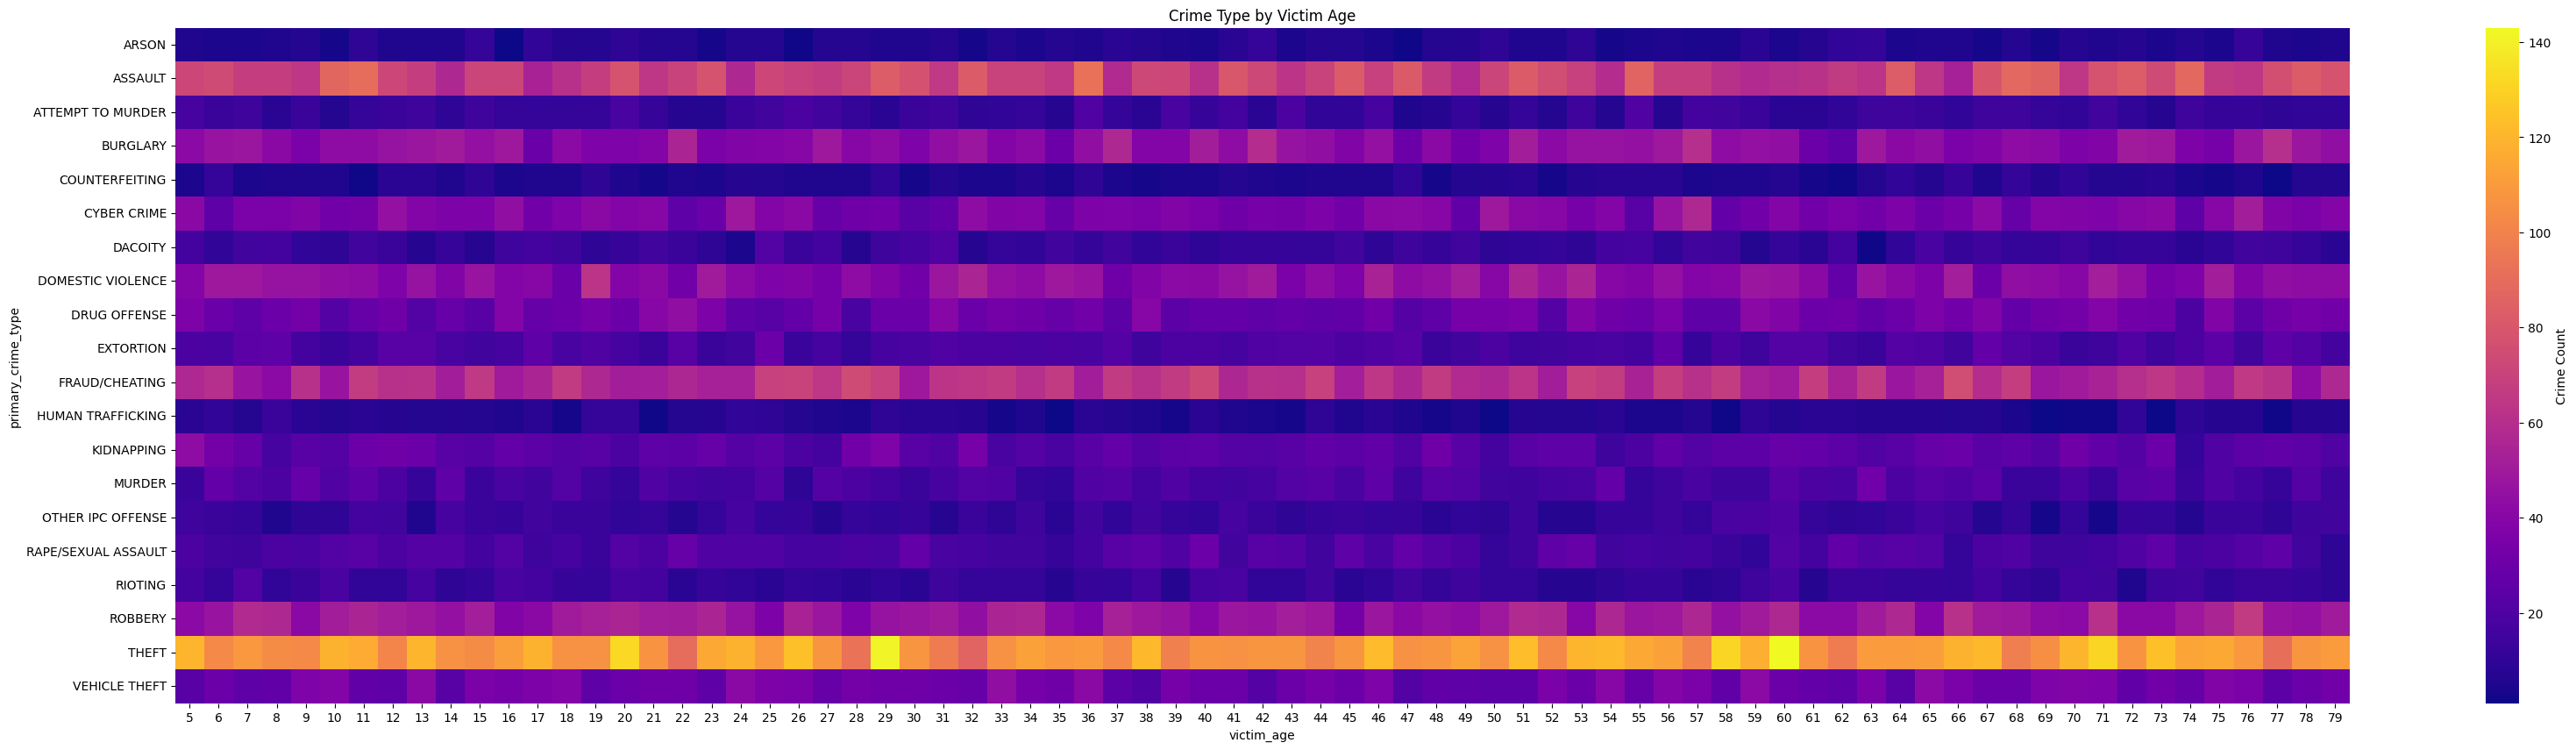

In [41]:
age_crime=df.groupby(['primary_crime_type','victim_age']).size().unstack(fill_value=0)
plt.figure(figsize=(40,10))
sns.heatmap(age_crime,cmap='plasma',cbar_kws={'label':'Crime Count'})
plt.title('Crime Type by Victim Age')


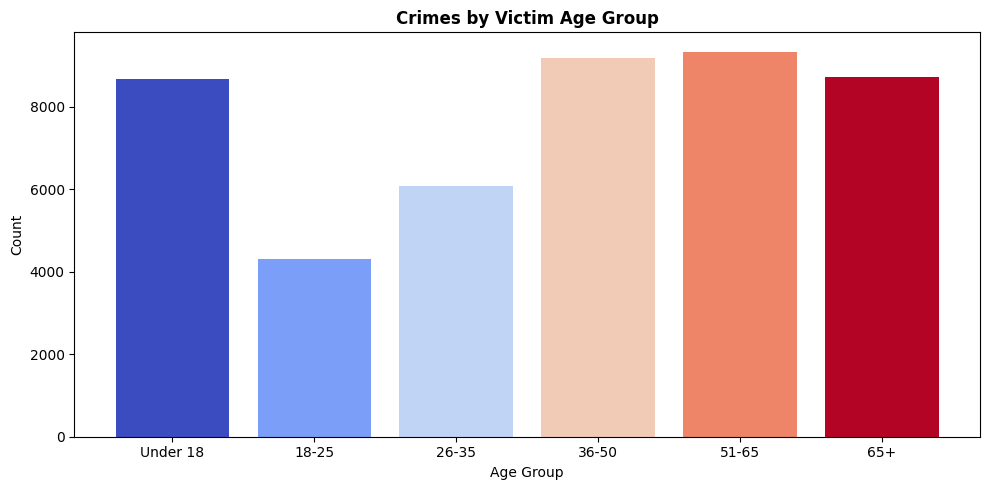

In [42]:
df['age_group'] = pd.cut(
    df['victim_age'],
    bins=[0,18,25,35,50,65,100],
    labels=['Under 18','18-25','26-35','36-50','51-65','65+']
)
age_counts = df['age_group'].value_counts().sort_index()
plt.figure(figsize=(10,5))
plt.bar(age_counts.index, age_counts.values,
        color=plt.cm.coolwarm(np.linspace(0,1,len(age_counts))))
plt.title('Crimes by Victim Age Group', fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

<Axes: xlabel='primary_crime_type', ylabel='location_type'>

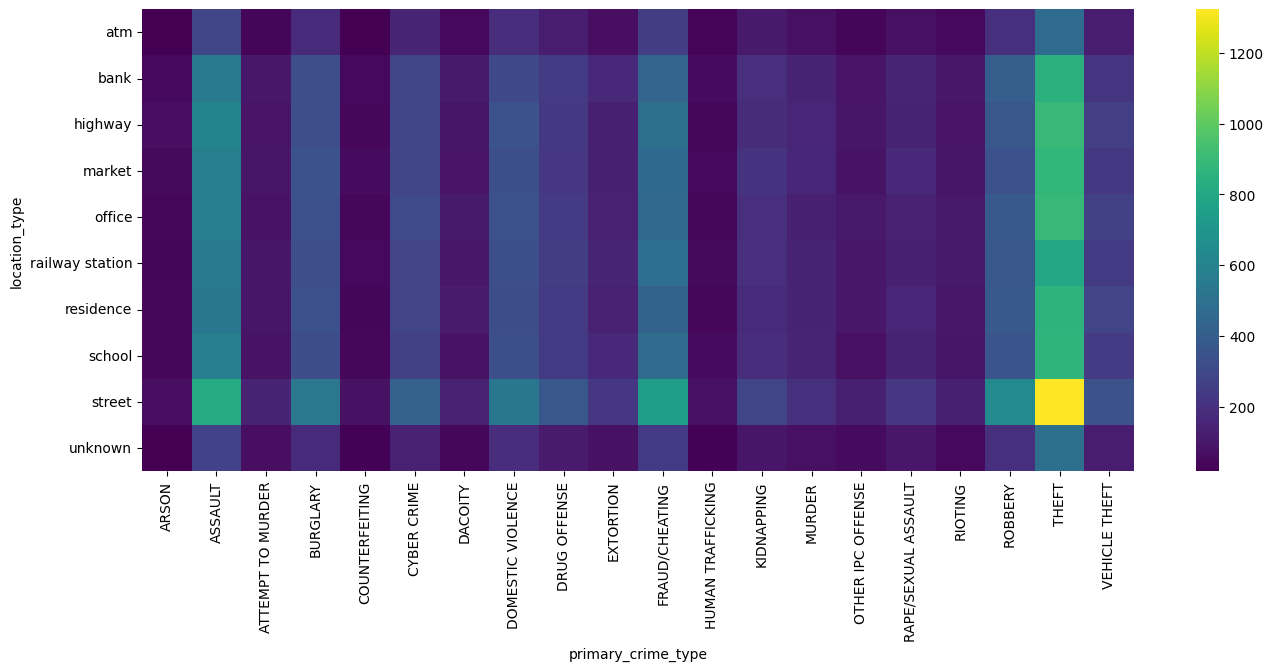

In [43]:
location_crime=df.groupby(['location_type','primary_crime_type']).size().unstack(fill_value=0)
plt.figure(figsize=(16,6))
sns.heatmap(location_crime,cmap='viridis')


Text(0, 0.5, 'Crime Count')

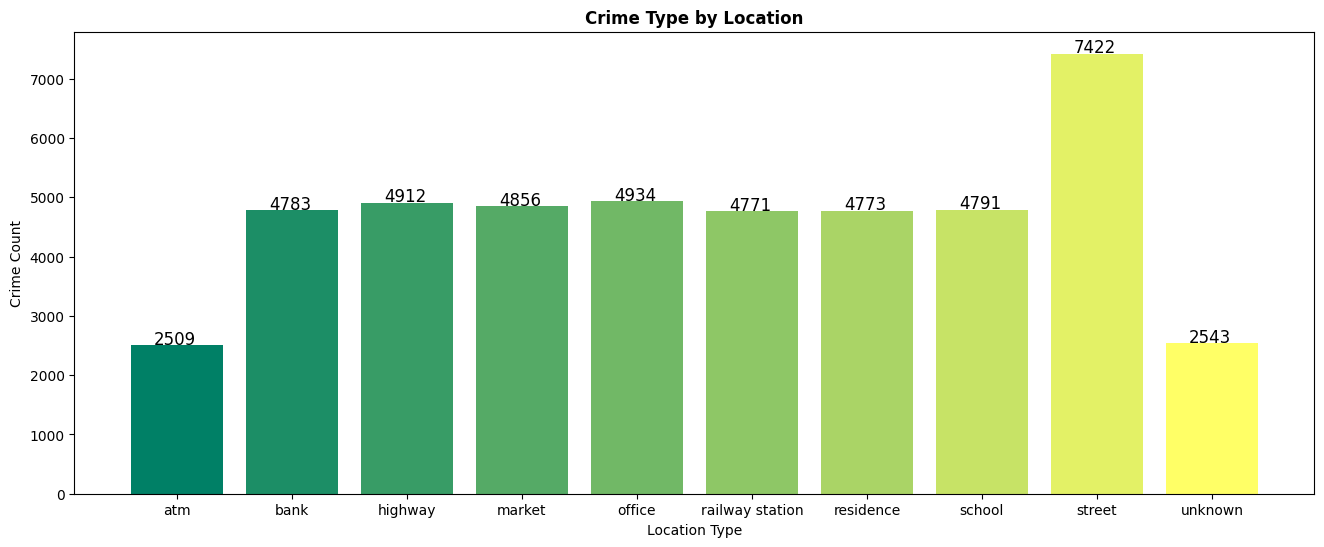

In [44]:
location_crime=df.groupby('location_type').size()
plt.figure(figsize=(16,6))
colors=plt.cm.summer(np.linspace(0,1,len(location_crime)))
location_plot=plt.bar(location_crime.index,location_crime.values,color=colors)
for bar,val in zip(location_plot,location_crime.values):
  plt.text(bar.get_x()+bar.get_width()/4,bar.get_height()+100 ,val,va='center',fontsize=12)
plt.title('Crime Type by Location',fontweight='bold')
plt.xlabel('Location Type')
plt.ylabel('Crime Count')

In [45]:
print("="*50)
print("   KEY INSIGHTS FROM EDA")
print("="*50)
print(f"\n Most Dangerous City:   {df['city'].value_counts().index[0]}")
print(f" Most Common Crime:     {df['primary_crime_type'].value_counts().index[0]}")
print(f" Peak Crime Hour:       {df['hour'].value_counts().index[0]}:00")
print(f" Most Dangerous Day:    {df['day_of_week'].value_counts().index[0]}")
print(f" Most Affected Gender:  {df['victim_gender'].value_counts().index[0]}")
print(f" Average Victim Age:    {df['victim_age'].mean():.1f} years")
print(f" Overall Arrest Rate:   {df['arrest_made'].mean()*100:.1f}%")
print(f" Safest City:           {df.groupby('city').size().idxmin()}")
print(f" Total Records:         {len(df):,}")

   KEY INSIGHTS FROM EDA

 Most Dangerous City:   Mumbai
 Most Common Crime:     THEFT
 Peak Crime Hour:       0:00
 Most Dangerous Day:    Friday
 Most Affected Gender:  male
 Average Victim Age:    42.0 years
 Overall Arrest Rate:   21.9%
 Safest City:           Guwahati
 Total Records:         46,294


In [48]:
!pip install mysql-connector-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.5/34.5 MB 51.5 MB/s eta 0:00:00
